# Baseline модели для прогнозирования продаж Favorita

## Подход к валидации

Для оценки качества моделей используем валидацию на **2 последних неделях обучающих данных** (30 июля-15 августа 2017). 

**Обоснование:**
- Тестовые данные в соревновании - это 2 недели после окончания тренировочного периода
- Валидация на аналогичном по длительности периоде непосредственно перед тестом близкую оценку того, как модель поведет себя на реальных данных

In [1]:
import gc
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast.models import AutoETS

sys.path.append('..')
from src.models.hierarchical_pipeline import HierarchicalForecaster
from src.models.naive_seasonal import NaiveSeasonal
from src.models.sf_adapter import StatsForecastAdapter
from src.utils.metrics import nwrmsle

In [2]:
RAW_DATA_DIR = r"..\data\raw_data"
PREP_DATA_DIR = r"..\data\prepared_data"

In [3]:
train = pd.read_parquet(os.path.join(PREP_DATA_DIR, "train_optimized.parquet"))
items = pd.read_csv(os.path.join(RAW_DATA_DIR, "items.csv"))
stores = pd.read_csv(os.path.join(RAW_DATA_DIR, "stores.csv"))

## Подготовка данных

Создаем три среза:
- Обучающая выборка: все данные до 29 июля 2017
- Валидационная выборка: 30 июля-15 августа 2017

In [4]:
item_weights = items.set_index('item_nbr')['perishable'].to_dict()
item_weights = {k: 1.25 if v == 1 else 1.0 for k, v in item_weights.items()}

train_end_date = pd.Timestamp('2017-07-29')
val_end_date = pd.Timestamp('2017-08-14')

train_data = train[train['date'] <= train_end_date].copy()
val_data = train[(train['date'] > train_end_date) & (train['date'] <= val_end_date)].copy()
val_data['weight'] = val_data['item_nbr'].map(item_weights).fillna(1.0)

print(f"Train: {len(train_data)} записей")
print(f"Val: {len(val_data)} записей")
print(f"Уникальных пар в train: {train_data.groupby(['store_nbr', 'item_nbr']).ngroups}")

Train: 102050552 записей
Val: 1686025 записей
Уникальных пар в train: 173487


# Константные предсказания

Для начала, нужно найти нулевую отправную точку. Посмотрим скоры константных предсказаний, чтобы далее можно было от чего-то отталкиваться

In [5]:
# Константа 0
zero_pred = np.zeros(len(val_data))
zero_score = nwrmsle(
    val_data['unit_sales'].values, 
    zero_pred, 
    val_data['weight'].values
)
print(f"Константа 0: {zero_score:.6f}")

# Константа (глобальное среднее)
global_mean = train_data['unit_sales'].mean()
mean_pred = np.full(len(val_data), global_mean)
mean_score = nwrmsle(
    val_data['unit_sales'].values, 
    mean_pred, 
    val_data['weight'].values
)
print(f"Глобальное среднее ({global_mean:.2f}): {mean_score:.6f}")

Константа 0: 1.916219
Глобальное среднее (8.50): 1.027685


Тут сразу обатим внимание и на реализаию весов для метрики. По условиям соревнования, скоропортящиеся продукты получают повышенный штраф, так как точное их прогнозирование более приоритетно для совершения закупок. В нашей реализации это учтено.

## Baseline 1: Naive Seasonal (период = 7 дней)

Самая простая модель: прогноз на основе последней известной недели.
Для каждой пары магазин-товар берем последние 7 дней продаж и повторяем их.

In [ ]:
# Группируем данные по парам магазин-товар
train_pairs = train_data.groupby(['store_nbr', 'item_nbr'])

In [7]:
total_pairs = train_data.groupby(['store_nbr', 'item_nbr']).ngroups

Тут использую в качестве NaiveSeasonal решение через numpy для векторизации и ускорения расчетов вместо импорта класса.

In [ ]:
start_time = time.time()
update_step = total_pairs // 10
next_update = update_step

# Предварительные расчеты
val_start_date = val_data['date'].min()
forecast_horizon = 16

# Группируем val_data
val_grouped = val_data.groupby(['store_nbr', 'item_nbr'])
val_pairs_set = set(val_grouped.groups.keys())

# Создаем словарь с данными валидации
val_dict = {}
for (store, item), group in val_grouped:
    val_dict[(store, item)] = group.sort_values('date').to_dict('records')

# Преобразуем даты в индексы
val_dates = sorted(val_data['date'].unique())
date_to_idx = {date: i for i, date in enumerate(val_dates)}

naive_predictions = []

for idx, ((store, item), group) in enumerate(train_pairs):
    # Прогресс
    if idx >= next_update:
        pct_done = (idx / total_pairs) * 100
        elapsed = time.time() - start_time
        if idx > 0:
            eta = (elapsed / idx) * (total_pairs - idx)
            print(f"Прогресс: {pct_done:.1f}% ({idx}/{total_pairs}), "
                  f"прошло: {elapsed:.1f}s, осталось: {eta:.1f}s")
        next_update += update_step
    
    # Проверяем, есть ли эта пара в валидации
    if (store, item) not in val_dict:
        continue
    
    # Получаем данные валидации
    val_rows = val_dict[(store, item)]
    
    # Получаем временной ряд
    y = group.sort_values('date')['unit_sales'].values
    
    if len(y) >= 7:
        # Прогноз через numpy
        last_season = y[-7:]
        n_repeats = (forecast_horizon // 7) + 1
        forecast = np.tile(last_season, n_repeats)[:forecast_horizon]
        
        # Добавляем все записи разом
        for row in val_rows:
            day_offset = date_to_idx[row['date']]
            naive_predictions.append({
                'store_nbr': store,
                'item_nbr': item,
                'date': row['date'],
                'actual': row['unit_sales'],
                'predicted': forecast[day_offset],
                'weight': row['weight']
            })
    else:
        # Нулевой прогноз
        for row in val_rows:
            naive_predictions.append({
                'store_nbr': store,
                'item_nbr': item,
                'date': row['date'],
                'actual': row['unit_sales'],
                'predicted': 0,
                'weight': row['weight']
            })

naive_results = pd.DataFrame(naive_predictions)

print(f"Обработка завершена! Всего пар: {total_pairs}, время: {time.time() - start_time:.1f}s")

Прогресс: 10.0% (17348/173487), прошло: 118.2s, осталось: 1063.8s
Прогресс: 20.0% (34696/173487), прошло: 122.4s, осталось: 489.5s
Прогресс: 30.0% (52044/173487), прошло: 125.8s, осталось: 293.5s
Прогресс: 40.0% (69392/173487), прошло: 129.4s, осталось: 194.1s
Прогресс: 50.0% (86740/173487), прошло: 132.6s, осталось: 132.7s
Прогресс: 60.0% (104088/173487), прошло: 136.0s, осталось: 90.7s
Прогресс: 70.0% (121436/173487), прошло: 139.3s, осталось: 59.7s
Прогресс: 80.0% (138784/173487), прошло: 143.6s, осталось: 35.9s
Прогресс: 90.0% (156132/173487), прошло: 147.3s, осталось: 16.4s
Прогресс: 100.0% (173480/173487), прошло: 150.8s, осталось: 0.0s
Обработка завершена! Всего пар: 173487, время: 182.7s


In [9]:
naive_score = nwrmsle(
    naive_results['actual'].values, 
    naive_results['predicted'].values,
    naive_results['weight'].values
)
print(f"Naive Seasonal NWRMSLE: {naive_score:.6f}")

Naive Seasonal NWRMSLE: 0.705290


In [10]:
gc.collect()

0

Результат получился достаточно хорошим и превосходящим константы. Это, в целом, достаточно ожидаемо, посокльку, как мы знаем из EDA, сезонность у этого датасета выражена достаточно ярко.

Далее есть очень важный момент:
* Датасет у нас ОЧЕНЬ большой, поэтому в последующих сравнениях использовать полный набор данных с моими мощностями уже не получится (я много и долго пробовал результат оказался очень печальным);
* Поскольку обучить модель NaiveSeasonal не сложно - она справилась с полным набором данных (и то учитываем, что она смотрела только на последние 7 наблюдений каждой пары, а не на несколько лет), но дальше такой роскоши уже не получится.

В связи с этим, мною было найдено решение в 2 вариантах. Первый - описан ниже и используется в этом ноутбуке и в ноутбуке `bonus_ml_hc.ipynb`. Второй метод будет описан в следующем ноутбуке - `03_ets.ipynb`.

## Baseline 2: AutoETS

В этом подходе используется AutoETS модель, подбирающая параметры автоматически.

Но важнее здесь обсудить именно метод её использования.  
Самое точное попадание будет в том случае, если каждая модель будет учиться под свой ряд. Глобальные модели можно было бы рассмотреть, но в нашем наборе данных получается примерно 170к пар магазин-товар и выстроить корректный пайплайн обучения и, главное, инференса под такой размах было бы слишком сложно в достаточно сжатый срок.  

Я попробовал найти гибридное решение. **А что если выделить кластеры среди наших пар и обучать модели на их уровне?**  
Как результат развития такой идеи у меня получился алгоритм, похожий по своей сути на иерархическую кластеризацию. 

Есть три ступени объединения рядов:
1. Общий уровень (Total) - все ряды усредняются между собой.
Тут мы хотим найти наиболее общие закономерности между рядами. Например, снова вспомним нашу сезонность :D

2. Уровень кластеров (Cluster) - объединение магазинов по их характеристикам. 
В данных изначально присутствует разбиение магазинов на кластеры (поле cluster в stores.csv), которые объединяют похожие по формату, размеру и ассортименту магазины. На этом уровне мы агрегируем продажи по всем товарам внутри каждого кластера, получая средние продажи для кластера в целом.

3. Уровень кластер-семейство (Cluster+Family) - наиболее детальный уровень агрегации.
Здесь мы группируем данные одновременно по кластеру магазинов и по семейству товаров (поле family в items.csv). Это позволяет учесть как специфику магазинов, так и категорию товаров, что дает более тонкую настройку прогнозов.

**Как это работает:**

На этапе обучения мы создаем три набора временных рядов, последовательно агрегируя 
исходные данные снизу вверх. Для каждого уровня обучается своя модель:
- Одна модель на общем уровне (Total)
- По одной модели на каждый кластер (всего 17 моделей)
- По одной модели на каждую комбинацию кластер-семейство (около 550 моделей)

Таким образом, вместо 170 000 индивидуальных моделей мы обучаем всего около 570 моделей, что делает подход вычислительно реализуемым.

**Инференс и дизагрегация:**

На этапе прогнозирования мы сначала получаем прогнозы от всех обученных моделей на соответствующих уровнях агрегации. Затем происходит обратный процесс - дизагрегация, то есть распределение агрегированных прогнозов на уровень отдельных магазинов и товаров.

Для этого используются заранее вычисленные пропорции:
- На основе исторических данных мы считаем, какую долю продаж кластера составляет каждый магазин
- Аналогично, какую долю продаж комбинации кластер-семейство составляет каждый конкретный товар

Итоговый прогноз для конкретной пары магазин-товар получается как взвешенная сумма прогнозов с двух уровней - кластерного и уровня кластер-семейство, с учетом соответствующих долей и поправочных коэффициентов масштабирования.

**Почему это работает:**

Такой подход позволяет учесть иерархическую структуру данных, сгладить шум на индивидуальном уровне за счет агрегации, и при этом получить интерпретируемые и вычислительно эффективные прогнозы. Модели на верхних уровнях видят общую картину и тренды, а дизагрегация возвращает эту информацию на нужный уровень детализации.

In [11]:
train_data = train_data[train_data['date'] >= pd.Timestamp('2017-01-01')].copy()

In [12]:
hier_forecaster = HierarchicalForecaster(stores, items)

In [13]:
aggregated_series = hier_forecaster.create_hierarchy(train_data)

Создание иерархии...
  Всего уникальных товаров: 3982
  Всего уникальных магазинов: 54
  Средние продажи total: 8.10
Пропорции вычислены:
  Средние продажи (total): 8.16
  Уникальных store_proportions: 54
  Уникальных item_proportions: 56330
  Total: 210 дней
  By cluster: 17 кластеров
  By cluster+family: 548 групп


In [14]:
print("\nАгрегированные ряды:")
for level_name, level_data in aggregated_series.items():
    if level_name == 'total':
        print(f"  {level_name}: {len(level_data)} дней, сумма продаж: {level_data['total_sales'].sum():.0f}")
    elif level_name == 'by_cluster':
        print(f"  {level_name}: {level_data['cluster'].nunique()} кластеров, записей: {len(level_data)}")
    elif level_name == 'by_cluster_family':
        n_groups = level_data.groupby(['cluster', 'family']).ngroups
        print(f"  {level_name}: {n_groups} групп, записей: {len(level_data)}")


Агрегированные ряды:
  total: 210 дней, сумма продаж: 1702
  by_cluster: 17 кластеров, записей: 3554
  by_cluster_family: 548 групп, записей: 108114


In [15]:
def create_ets_adapter(season_length=7):
    """Фабрика для создания адаптеров AutoETS"""
    return StatsForecastAdapter(
        model_class=AutoETS,
        model_params={'season_length': season_length}
    )

# Использование
hier_forecaster.fit_aggregated(
    model_class=create_ets_adapter,
    model_params={'season_length': 7},
    max_history=90
)

Обучение агрегированных моделей...
  Уровень Total...
  Уровень Clusters...
  Уровень Cluster+Family...
    Обработано 100/548 групп
    Обработано 200/548 групп
    Обработано 300/548 групп
    Обработано 400/548 групп
    Обработано 500/548 групп
Обучено моделей:
  Total: 1
  Clusters: 17
  Cluster+Family: 546


In [16]:
# Делаем прогнозы на агрегированных уровнях
start_date = val_data['date'].min()
horizon = (val_data['date'].max() - val_data['date'].min()).days + 1

forecasts = hier_forecaster.predict_aggregated(
    horizon=horizon,
    start_date=start_date
)

Прогнозирование на 16 дней...
  Всего кластеров: 17
  Всего cluster+family: 546


In [17]:
# Получаем все уникальные пары из валидации
val_pairs = list(val_data.groupby(['store_nbr', 'item_nbr']).groups.keys())
print(f"Всего уникальных пар в валидации: {len(val_pairs)}")

Всего уникальных пар в валидации: 146894


In [18]:
# Дизагрегируем прогнозы до уровня магазин-товар
start_time = time.time()

val_predictions = hier_forecaster.disaggregate_to_store_item(
    forecasts=forecasts,
    test_pairs=val_pairs
)

elapsed = time.time() - start_time
print(f"Дизагрегация завершена за {elapsed:.1f} секунд")
print(f"Получено прогнозов: {len(val_predictions)}")

Дизагрегация прогнозов до уровня магазин-товар...
  Средние продажи (total): 8.16
  Форма total прогноза: (16,)
  Прогресс: 0.0% (0/146894)
  Прогресс: 10.0% (14689/146894)
  Прогресс: 20.0% (29378/146894)
  Прогресс: 30.0% (44067/146894)
  Прогресс: 40.0% (58756/146894)
  Прогресс: 50.0% (73445/146894)
  Прогресс: 60.0% (88134/146894)
  Прогресс: 70.0% (102823/146894)
  Прогресс: 80.0% (117512/146894)
  Прогресс: 90.0% (132201/146894)
  Прогресс: 100.0% (146890/146894)
  Дизагрегация завершена. Всего прогнозов: 2350304
Дизагрегация завершена за 270.6 секунд
Получено прогнозов: 2350304


In [19]:
# Мерджим с actual для оценки
print("Оценка качества...")
val_with_pred = val_data.merge(
    val_predictions[['store_nbr', 'item_nbr', 'date', 'predicted']],
    on=['store_nbr', 'item_nbr', 'date'],
    how='left'
)

# Проверим, сколько записей не получили прогноз
missing_pred = val_with_pred['predicted'].isna().sum()
if missing_pred > 0:
    print(f"Предупреждение: {missing_pred} записей ({missing_pred/len(val_with_pred)*100:.2f}%) без прогноза")
    val_with_pred['predicted'] = val_with_pred['predicted'].fillna(0)

Оценка качества...


In [20]:
# Считаем метрику
score = nwrmsle(
    val_with_pred['unit_sales'].values,
    val_with_pred['predicted'].values,
    val_with_pred['weight'].values
)
print(f"Иерархический AutoETS NWRMSLE: {score:.6f}")

Иерархический AutoETS NWRMSLE: 1.420959


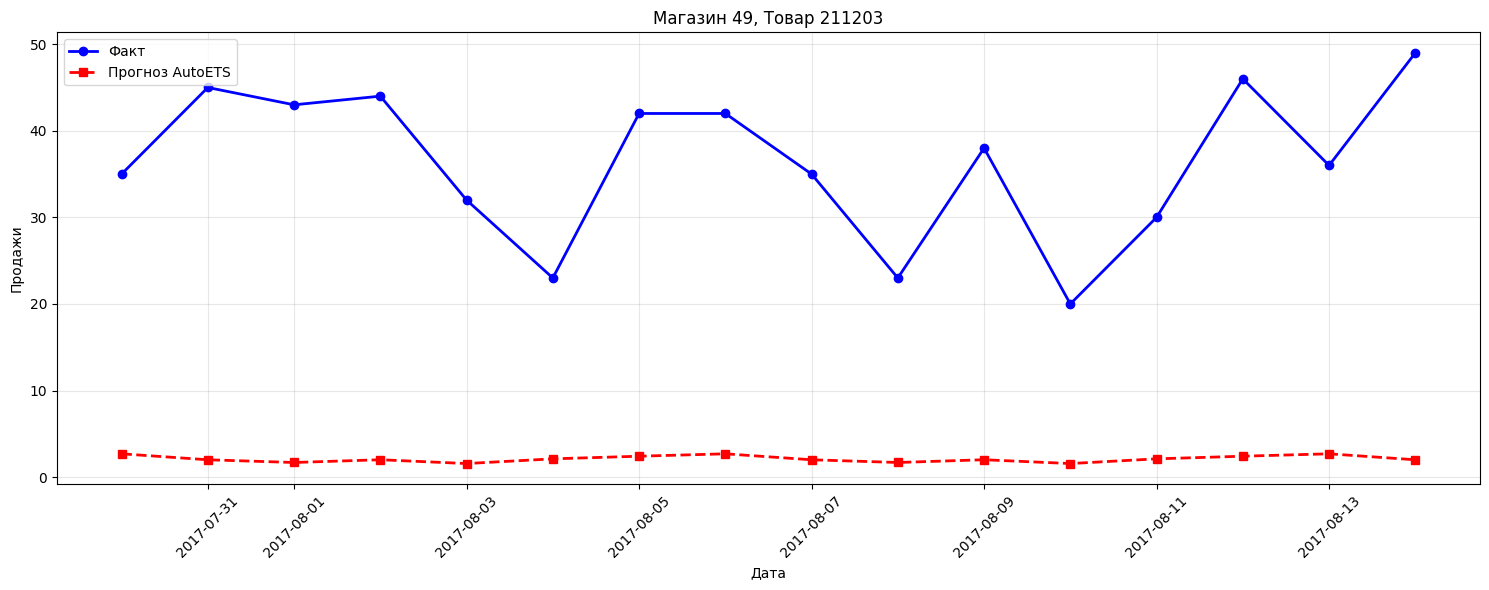

In [21]:
example_store, example_item = 49, 211203
example_data = val_with_pred[
    (val_with_pred['store_nbr'] == example_store) & 
    (val_with_pred['item_nbr'] == example_item)
].sort_values('date')

if len(example_data) > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(example_data['date'], example_data['unit_sales'], 'b-', label='Факт', linewidth=2, marker='o')
    plt.plot(example_data['date'], example_data['predicted'], 'r--', label='Прогноз AutoETS', linewidth=2, marker='s')
    plt.title(f'Магазин {example_store}, Товар {example_item}')
    plt.xlabel('Дата')
    plt.ylabel('Продажи')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Пришло время проанализировать результат такого подхода.

И на графике сразу виден главный недостаток - разнородные товары по среднему в рамках одного кластера. Если в один кластер попадают много рядов, моделям становится тяжело в это попасть. Однако можно обратить внимание, что по форме прогноз все же напоминает факт. Основная проблема в масштабе.

Скор 1.420959 - это хуже константы (но все ещё лучше нулей :D), однако запомним его, чтобы мы смогли сравнить его с ML подходом.  
Понятное дело, что метод далек от идеального из-за слишком грубого объединения, но мы, тем не менее, сможем сравнить модели между собой и понять, будет ли в аналогичной ситуации прирост у ML решения.

# Итоговые результаты

| Подход | NWRMSLE |
|--------|------------|
| Константа 0 | 1.916219 |
| Константа Глобальное среднее | 1.027685 |
| NaiveSeasonal | 0.705290 |
| AutoETS с иерархическим подходом | 1.420959 |